# ResNet50 Model

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

### Dataset and DataLoader

In [2]:
dataset = 'dataset_224x224'

class MVTecDataset(Dataset):
    def __init__(self, dataset_path, transform=None, mode="train"):
        super().__init__()
        self.transform = transform
        self.data = []
        
        categories = sorted([c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))])
        
        for category in categories:
            if mode == "train":
                good_path = os.path.join(dataset_path, category, "train", "good")
                for filename in os.listdir(good_path):
                    self.data.append((os.path.join(good_path, filename), 0))
                
                test_path = os.path.join(dataset_path, category, "test")
                for subfolder in os.listdir(test_path):
                    if subfolder != "good":
                        full_path = os.path.join(test_path, subfolder)
                        images = os.listdir(full_path)
                        train_split = int(len(images) * 0.7)
                        for filename in images[:train_split]:
                            self.data.append((os.path.join(full_path, filename), 1))
            
            elif mode == "test":
                test_path = os.path.join(dataset_path, category, "test")
                for subfolder in os.listdir(test_path):
                    full_path = os.path.join(test_path, subfolder)
                    images = os.listdir(full_path)
                    if subfolder == "good":
                        for filename in images:
                            self.data.append((os.path.join(full_path, filename), 0))
                    else:
                        test_split = int(len(images) * 0.7)
                        for filename in images[test_split:]:
                            self.data.append((os.path.join(full_path, filename), 1))
        
        np.random.shuffle(self.data)
        print(f"[{mode}] Total images: {len(self.data)}")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        path, label = self.data[index]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = MVTecDataset(dataset, transform=transform, mode="train")
test_dataset = MVTecDataset(dataset, transform=transform, mode="test")

labels = [l for _, l in train_dataset.data]
print(f"Train - good: {labels.count(0)}, defect: {labels.count(1)}")

weights = torch.DoubleTensor([1.0/labels.count(0) if l == 0 else 1.0/labels.count(1) for l in labels])
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

[train] Total images: 4478
[test] Total images: 876
Train - good: 3629, defect: 849
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


### ResNet50 model

In [3]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

print(model.fc)

Linear(in_features=2048, out_features=2, bias=True)


### Training

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 20
loss_list = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_dataloader)
    loss_list.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "models/resnet50_model.pth")

Epoch [1/20] | Loss: 0.4348
Epoch [2/20] | Loss: 0.1690
Epoch [3/20] | Loss: 0.0648
Epoch [4/20] | Loss: 0.0289
Epoch [5/20] | Loss: 0.0279
Epoch [6/20] | Loss: 0.0119
Epoch [7/20] | Loss: 0.0211
Epoch [8/20] | Loss: 0.0137
Epoch [9/20] | Loss: 0.0029
Epoch [10/20] | Loss: 0.0024
Epoch [11/20] | Loss: 0.0032
Epoch [12/20] | Loss: 0.0066
Epoch [13/20] | Loss: 0.0111
Epoch [14/20] | Loss: 0.0041
Epoch [15/20] | Loss: 0.0013
Epoch [16/20] | Loss: 0.0018
Epoch [17/20] | Loss: 0.0065
Epoch [18/20] | Loss: 0.0012
Epoch [19/20] | Loss: 0.0006
Epoch [20/20] | Loss: 0.0039


### Loss graph

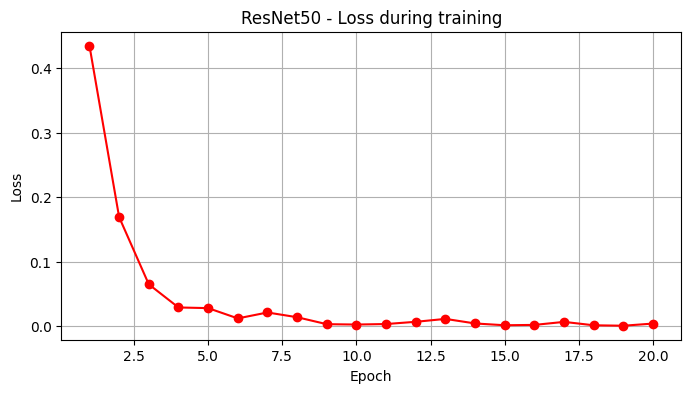

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs+1), loss_list, marker='o', color='red')
plt.title("ResNet50 - Loss during training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Evaluation

In [6]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        output = model(images)
        predictions = output.argmax(axis=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f"Accuracy: {correct/total*100:.2f}%")

Accuracy: 88.58%
